# LightGBM Fraud Detection Model

This notebook develops a LightGBM classifier for credit card fraud detection using the processed dataset from the feature engineering pipeline.

The workflow includes baseline modeling, cross-validation, hyperparameter optimization using Optuna, threshold optimization, probability calibration, SHAP explainability, feature importance analysis, and final model evaluation.

### Import Required Libraries

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from lightgbm import LGBMClassifier
import lightgbm as lgb
from collections import Counter
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from imblearn.combine import SMOTETomek
import optuna
import shap
shap.initjs()
optuna.logging.set_verbosity(optuna.logging.ERROR)

### Load Processed Data

In [23]:
X_train = joblib.load("data/processed/lightgbm/X_train_lgb.pkl")
X_test = joblib.load("data/processed/lightgbm/X_test_lgb.pkl")
y_train = joblib.load("data/processed/lightgbm/y_train.pkl")
y_test = joblib.load("data/processed/lightgbm/y_test.pkl")

In [4]:
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Train Shape: (254705, 33)
Test Shape : (84902, 33)

Training Class Distribution
is_fraud
0    253369
1      1336
Name: count, dtype: int64

Testing Class Distribution
is_fraud
0    84456
1      446
Name: count, dtype: int64


In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   amt                       254705 non-null  float64
 1   hour                      254705 non-null  int32  
 2   day                       254705 non-null  int32  
 3   weekday                   254705 non-null  int32  
 4   month                     254705 non-null  int32  
 5   age                       254705 non-null  int64  
 6   distance                  254705 non-null  float64
 7   is_night                  254705 non-null  int32  
 8   hour_sin                  254705 non-null  float64
 9   hour_cos                  254705 non-null  float64
 10  weekday_sin               254705 non-null  float64
 11  weekday_cos               254705 non-null  float64
 12  is_weekend                254705 non-null  int32  
 13  business_hours            254705 non-null  i

In [24]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print("Testing Report")
    print("=" * 60)
    print(classification_report(y_test, test_pred, digits=4))

    print("=" * 60)
    print("ROC-AUC")
    print("=" * 60)
    print(f"Train : {roc_auc_score(y_train, train_prob):.6f}")
    print(f"Test  : {roc_auc_score(y_test, test_prob):.6f}")

    print("=" * 60)
    print("PR-AUC")
    print("=" * 60)
    print(f"Average Precision : {average_precision_score(y_test, test_prob):.6f}")

## Baseline LightGBM Model

- Uses LightGBM with **default binary classification settings**  
- Enables `is_unbalance=True` to automatically handle severe class imbalance  
- No manual hyperparameter tuning applied  


In [23]:
baseline_model = LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    is_unbalance=True,        
    random_state=42,
    verbosity=-1,
    device="gpu"  
)

In [24]:
evaluate_model(baseline_model,X_train,X_test,y_train,y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9993    0.9710    0.9850     84456
           1     0.1372    0.8722    0.2371       446

    accuracy                         0.9705     84902
   macro avg     0.5683    0.9216    0.6110     84902
weighted avg     0.9948    0.9705    0.9810     84902

ROC-AUC
Train : 0.969327
Test  : 0.904150
PR-AUC
Average Precision : 0.132883


## Baseline Model Cross Validation

In [8]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

roc_scores = []
pr_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[valid_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    baseline_model.fit( X_tr, y_tr)

    val_prob = baseline_model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, val_prob)
    pr = average_precision_score(y_val, val_prob)

    roc_scores.append(roc)
    pr_scores.append(pr)

    print(f"Fold {fold} | "f"ROC-AUC: {roc:.6f} | "f"PR-AUC: {pr:.6f}")

Fold 1 | ROC-AUC: 0.879266 | PR-AUC: 0.043200
Fold 2 | ROC-AUC: 0.916009 | PR-AUC: 0.143640
Fold 3 | ROC-AUC: 0.920803 | PR-AUC: 0.113259
Fold 4 | ROC-AUC: 0.897250 | PR-AUC: 0.121347
Fold 5 | ROC-AUC: 0.914121 | PR-AUC: 0.194834


## Optuna Training Strategy

- **5-fold Stratified Cross Validation** ensures reliable and stable model evaluation while preserving the class distribution in each fold.
- **SMOTE-Tomek** is applied **only to the training portion of each fold** to handle class imbalance and prevent data leakage.
- The optimization objective is to **maximize PR-AUC (Average Precision)**, making the model more effective at identifying fraudulent transactions in a highly imbalanced dataset.
- The best-performing hyperparameters are selected based on the **mean PR-AUC across all validation folds**, ensuring the final model generalizes well to unseen data.

In [7]:
smote_tomek = SMOTETomek(random_state=42)

def objective(trial):
    # Hyperparameter 
    params = {
        "objective": "binary",
        "metric": "average_precision",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
        "device": "gpu",
        "max_bin": 63,
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1,
    }

    pr_scores = []

    # Cross-validation loop
    for train_idx, valid_idx in skf.split(X_train, y_train):
        # Split data
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        # Resample with SMOTE-Tomek
        X_tr_resampled, y_tr_resampled = smote_tomek.fit_resample(X_tr, y_tr)

        # Train LightGBM model
        model = LGBMClassifier(**params)
        model.fit(
            X_tr_resampled,
            y_tr_resampled,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                LightGBMPruningCallback(trial, "average_precision"),
            ],
        )

        # Evaluate with Precision-Recall AUC
        val_prob = model.predict_proba(X_val)[:, 1]
        pr = average_precision_score(y_val, val_prob)
        pr_scores.append(pr)

    return np.mean(pr_scores)


In [8]:
study = optuna.create_study(
    direction="maximize",
    study_name="LightGBM_PR_AUC",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=20
    )
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

In [13]:
params =  study.best_params
print("=" * 60)
print("Best PR-AUC")
print("=" * 60)
print(study.best_value)

print()

print("=" * 60)
print("Best Parameters")
print("=" * 60)

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best PR-AUC
0.923581434832799

Best Parameters
learning_rate: 0.17129698917803388
n_estimators: 571
num_leaves: 138
max_depth: 10
min_child_samples: 76
subsample: 0.8696138822091872
colsample_bytree: 0.7503590781040156
reg_alpha: 0.002920920152180285
reg_lambda: 0.37587885895244016
min_split_gain: 0.05182397802053926


### Save Optuna Hyperparameters

In [15]:
joblib.dump(params, "models/lgboost/lgboost_optuna_study.pkl")
params = joblib.load("models/lgboost/lgboost_optuna_study.pkl")

## Apply SMOTE on Training Data

In [28]:
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape :", X_train.shape)
print("Resampled Training Shape:", X_train_resampled.shape)

print("\nOriginal Class Distribution")
print(y_train.value_counts())

print("\nResampled Class Distribution")
print(y_train_resampled.value_counts())

Original Training Shape : (254705, 33)
Resampled Training Shape: (506712, 33)

Original Class Distribution
is_fraud
0    253369
1      1336
Name: count, dtype: int64

Resampled Class Distribution
is_fraud
0    253356
1    253356
Name: count, dtype: int64


## LightGBM (Best Parameters)

In [29]:
lgb_optuna = LGBMClassifier(
    **params,
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    device="gpu",
    verbosity=-1,
    random_state=42,
    n_jobs=-1
)

evaluate_model(lgb_optuna,X_train_resampled,X_test,y_train_resampled,y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9990    0.9996    0.9993     84456
           1     0.9241    0.8184    0.8680       446

    accuracy                         0.9987     84902
   macro avg     0.9615    0.9090    0.9337     84902
weighted avg     0.9986    0.9987    0.9987     84902

ROC-AUC
Train : 1.000000
Test  : 0.997116
PR-AUC
Average Precision : 0.922084


## LightGBM With Weights

In [30]:
# scale_pos_weight ≈ negatives / positives
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

lgb_with_weights = LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    class_weight={0:1, 1:scale_pos_weight},  # Explicit weights
    device="gpu",
    random_state=42,
    n_jobs=-1
)
evaluate_model(lgb_with_weights,X_train,X_test,y_train,y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9997    0.9937    0.9967     84456
           1     0.4435    0.9507    0.6049       446

    accuracy                         0.9935     84902
   macro avg     0.7216    0.9722    0.8008     84902
weighted avg     0.9968    0.9935    0.9947     84902

ROC-AUC
Train : 0.999929
Test  : 0.998265
PR-AUC
Average Precision : 0.913543


## Threshold Optimization

In [17]:
def threshold_optimization(model, X_test, y_test):

    y_prob = model.predict_proba(X_test)[:, 1]
    results = []
    thresholds = np.arange(0.10, 1.00, 0.05)

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "False Positives": fp,
            "False Negatives": fn
        })

    results = pd.DataFrame(results)
    return results

In [47]:
threshold_optuna = threshold_optimization(
    lgb_optuna,
    X_test,
    y_test
)

threshold_with_wights = threshold_optimization(
    lgb_with_weights,
    X_test,
    y_test
)

In [48]:
display(threshold_optuna)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.804527,0.876682,0.839056,95,55
1,0.15,0.852747,0.869955,0.861265,67,58
2,0.20,0.871041,0.863229,0.867117,57,61
3,0.25,0.888372,0.856502,0.872146,48,64
4,0.30,0.897375,0.843049,0.869364,43,70
5,0.35,0.909756,0.836323,0.871495,37,73
6,0.40,0.913366,0.827354,0.868235,35,77
7,0.45,0.919598,0.820628,0.867299,32,80
8,0.50,0.924051,0.818386,0.868014,30,81
9,0.55,0.928021,0.809417,0.864671,28,85


In [49]:
display(threshold_with_wights)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.227225,0.973094,0.368421,1476,12
1,0.15,0.262902,0.970852,0.413760,1214,13
2,0.20,0.298549,0.968610,0.456418,1015,14
3,0.25,0.329008,0.966368,0.490888,879,15
4,0.30,0.353859,0.966368,0.518029,787,15
5,0.35,0.378307,0.961883,0.543038,705,17
6,0.40,0.400939,0.957399,0.565189,638,19
7,0.45,0.418972,0.950673,0.581619,588,22
8,0.50,0.443515,0.950673,0.604850,532,22
9,0.55,0.467113,0.939462,0.623976,478,27


After threshold optimization, the SMOTE-Tomek model consistently achieved:

- Higher Precision
- Higher F1-score
- Fewer False Positives
- Fewer False Negatives
- Comparable Recall

Although the class-weighted model achieved very high recall at lower thresholds, it produced substantially more false positives. The SMOTE-Tomek approach provided a better balance between fraud detection and false alarms, making it the preferred model for the final pipeline.

In [31]:
# Predictions from both models
y_pred_optuna = lgb_optuna.predict(X_test)
y_pred_weights = lgb_with_weights.predict(X_test)

# Probabilities from both models
y_prob_optuna  = lgb_optuna.predict_proba(X_test)[:, 1]
y_prob_weights = lgb_with_weights.predict_proba(X_test)[:, 1]

## Confusion Matrix

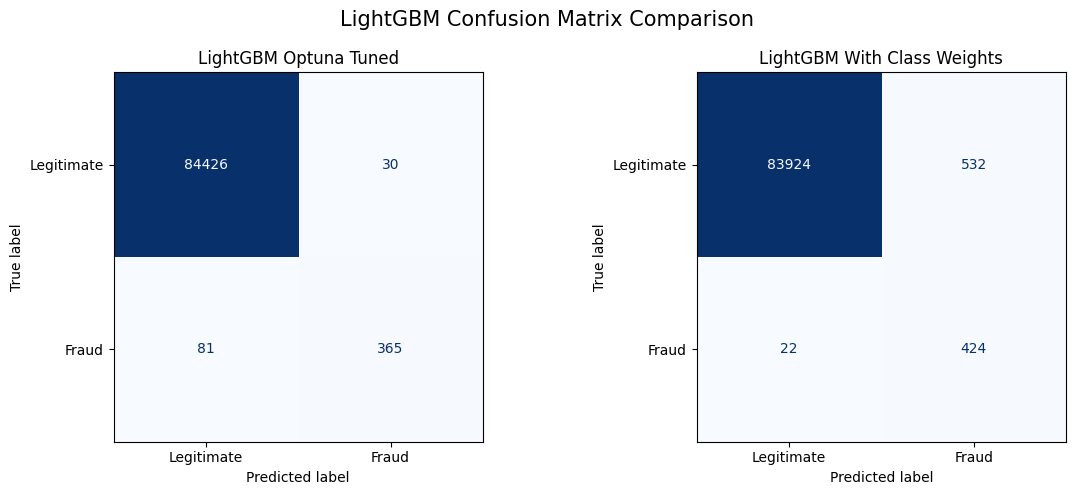

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix for Optuna-tuned model
cm_optuna = confusion_matrix(y_test, y_pred_optuna)
disp_optuna = ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=["Legitimate", "Fraud"]
)
disp_optuna.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("LightGBM Optuna Tuned")

# Confusion matrix for Weighted model
cm_weights = confusion_matrix(y_test, y_pred_weights)
disp_weights = ConfusionMatrixDisplay(
    confusion_matrix=cm_weights,
    display_labels=["Legitimate", "Fraud"]
)
disp_weights.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("LightGBM With Class Weights")

for ax in axes:
    ax.grid(False)

plt.suptitle("LightGBM Confusion Matrix Comparison", fontsize=15)
plt.tight_layout()
plt.show()


## ROC Curve

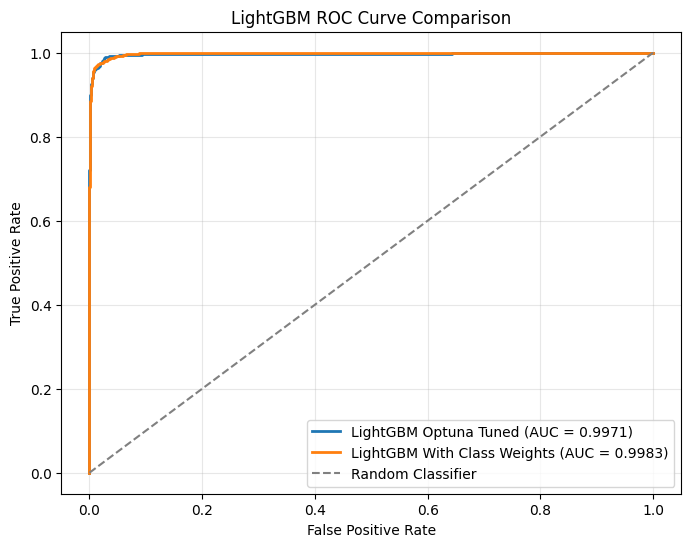

In [44]:
# ROC curve values
fpr_optuna, tpr_optuna, _   = roc_curve(y_test, y_prob_optuna)
fpr_weights, tpr_weights, _ = roc_curve(y_test, y_prob_weights)

# AUC scores
auc_optuna  = roc_auc_score(y_test, y_prob_optuna)
auc_weights = roc_auc_score(y_test, y_prob_weights)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_optuna, tpr_optuna, linewidth=2,
         label=f"LightGBM Optuna Tuned (AUC = {auc_optuna:.4f})")

plt.plot(fpr_weights, tpr_weights, linewidth=2,
         label=f"LightGBM With Class Weights (AUC = {auc_weights:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## Probability Calibration


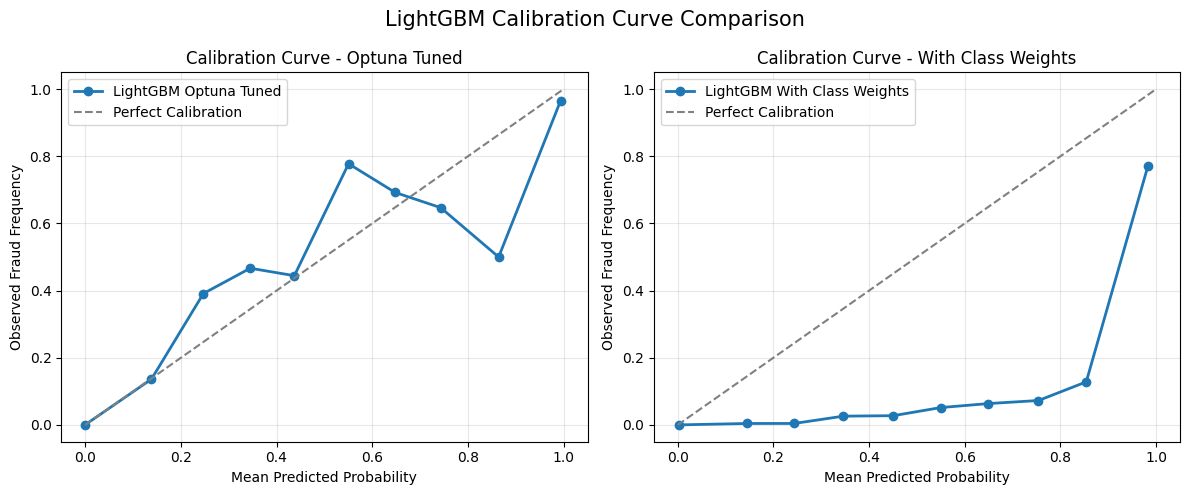

In [33]:
# Calibration curve
prob_true_optuna, prob_pred_optuna = calibration_curve(
    y_test,
    y_prob_optuna,   
    n_bins=10,
    strategy="uniform"
)

prob_true_weights, prob_pred_weights = calibration_curve(
    y_test,
    y_prob_weights,  
    n_bins=10,
    strategy="uniform"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Optuna-tuned model calibration curve
axes[0].plot(prob_pred_optuna, prob_true_optuna, marker="o", linewidth=2,
             label="LightGBM Optuna Tuned")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[0].set_title("Calibration Curve - Optuna Tuned")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Observed Fraud Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Weighted model calibration curve
axes[1].plot(prob_pred_weights, prob_true_weights, marker="o", linewidth=2,
             label="LightGBM With Class Weights")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[1].set_title("Calibration Curve - With Class Weights")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Fraud Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("LightGBM Calibration Curve Comparison", fontsize=15)
plt.tight_layout()
plt.show()


- The **Optuna + SMOTE-Tomek** model produces probability estimates that are generally closer to the perfect calibration line, indicating more reliable confidence scores.
- The **class-weighted** model deviates substantially from the ideal calibration curve, suggesting that it tends to assign overly confident probabilities to fraud predictions.
- Although the class-weighted model achieves high recall, its probability estimates are less representative of the true fraud likelihood.
- Better calibration improves the reliability of probability-based decisions, such as threshold optimization and risk scoring.
- Overall, the **Optuna + SMOTE-Tomek** model demonstrates superior probability calibration and is selected as the final LightGBM model.

## SHAP Analysis

In [50]:
explainer = shap.TreeExplainer(lgb_optuna)
shap_values = explainer.shap_values(X_test)

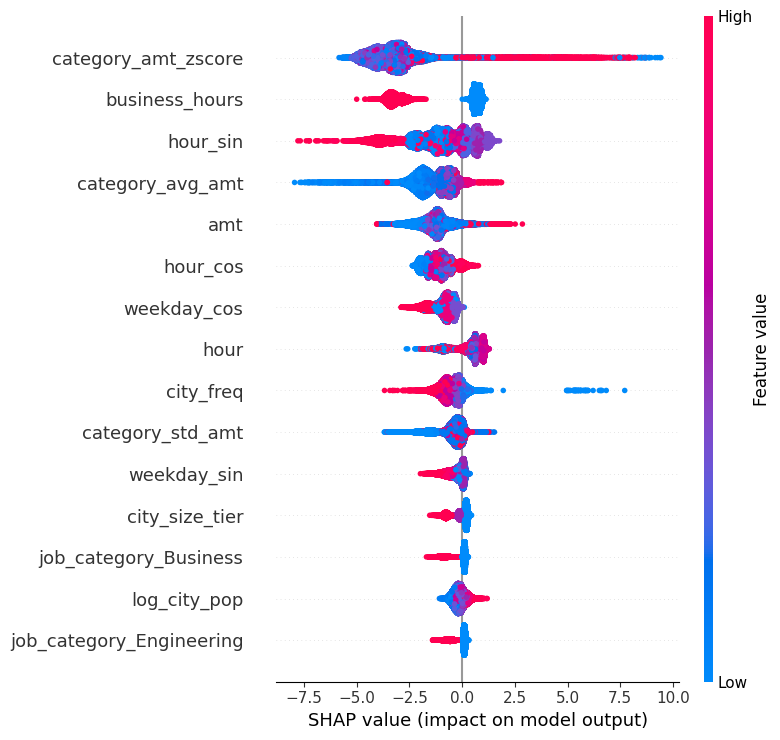

In [51]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

- **`category_amt_zscore`** → Key fraud signal. Large deviations from a customer’s usual spending strongly increase fraud probability.
- **Odd hours** → Transactions outside normal business hours are more suspicious, showing time-of-day matters.
- **Spending features** (`category_avg_amt`, `amt`) → Help detect abnormal purchase values compared to typical behavior.
- **Cyclic time features** (`hour_sin`, `hour_cos`, `weekday_sin`, `weekday_cos`) → Capture daily/weekly fraud patterns (e.g., late-night or weekend spikes).
- **Overall insight** → Model mainly relies on **behavioral spending patterns** and **transaction timing**, while demographics and location add supportive context.


### SHAP Waterfall Plot 

In [52]:
fraud_index = y_test[y_test == 1].index[0]

position = X_test.index.get_loc(fraud_index)

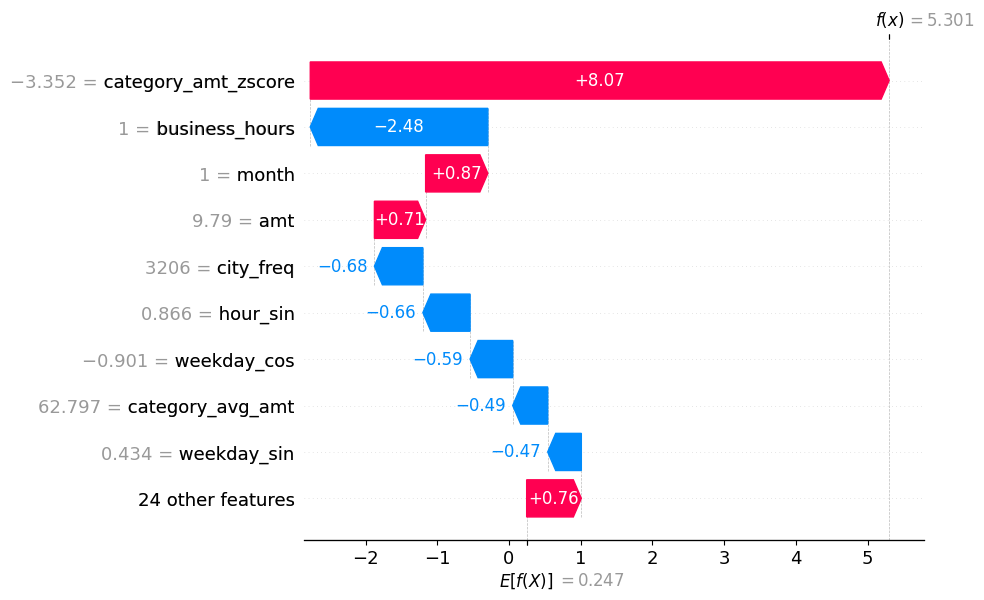

In [53]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test.iloc[position],
        feature_names=X_test.columns
    )
)


- **Purpose** → Shows how each feature shifts the model’s output from baseline to final fraud prediction for one transaction.
- **category_amt_zscore** → strongest driver of fraud prediction; abnormal transaction amounts raise risk.  
- **business_hours** → major negative contributor; transactions during normal hours reduce fraud likelihood.  
- **Other features** → smaller positive/negative effects fine‑tune the decision, but the model is mainly driven by amount anomalies and timing patterns.
- **Overall insight** → Fraud is mainly flagged by **unusual spending behavior**, with timing and location features fine‑tuning the prediction.


## Feature Importance

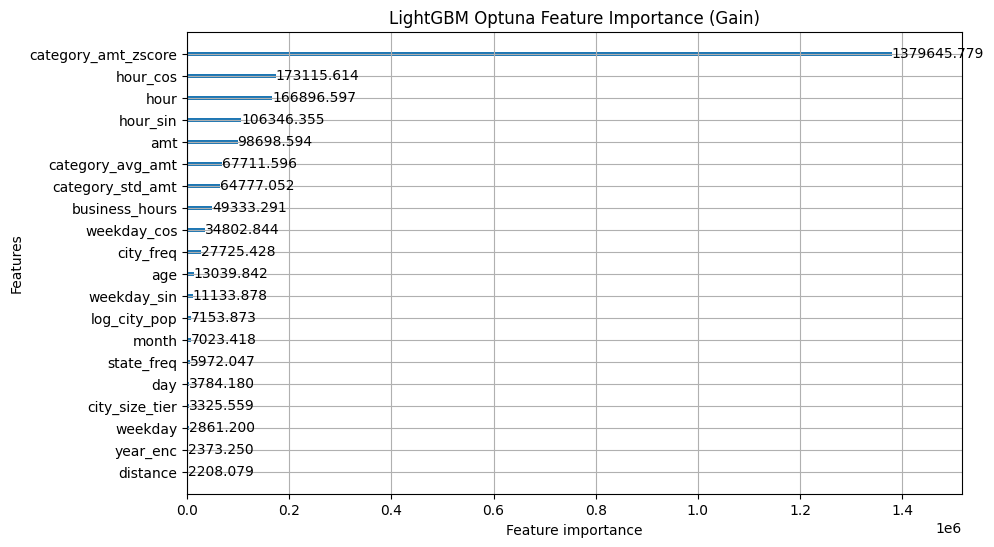

In [56]:
# gain-based feature importance
lgb.plot_importance(
    lgb_optuna,
    importance_type="gain",  
    max_num_features=20,     
    figsize=(10, 6)
)
plt.title("LightGBM Optuna Feature Importance (Gain)")
plt.show()


### Save Model

In [55]:
joblib.dump(lgb_optuna, "artifacts/lgboost/lgb_model.pkl")

['artifacts/lgboost/lgb_model.pkl']